In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
os.chdir(r"C:\Kaggle_Competition\Playground\S6E6-STELLAR-CLASS")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import QMCSampler, TPESampler
import config
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
optuna.logging.set_verbosity(verbosity=optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
import warnings
from optuna.exceptions import ExperimentalWarning
warnings.filterwarnings("ignore", category=ExperimentalWarning)

In [9]:
train = pd.read_csv("data/raw/train.csv")
test = pd.read_csv("data/raw/test.csv")

train_ids = train[config.ID_COL].values
test_ids = test[config.ID_COL].values

y = train[config.TARGET_COL]

enc = LabelEncoder()
y = enc.fit_transform(y)

print(f"Shape of train data: {train.shape}")
print(f"Shape of test data: {test.shape}")

Shape of train data: (577347, 12)
Shape of test data: (247435, 11)


### Blending

lgbm alone: 0.968158
xgbm alone: 0.968318
realmlp alone: 0.968908
tabpfn alone: 0.964797
histgbm alone: 0.964734
catgbm_ord alone: 0.962185
catgbm alone: 0.968922
resnet alone: 0.946722
stack alone: 0.970279


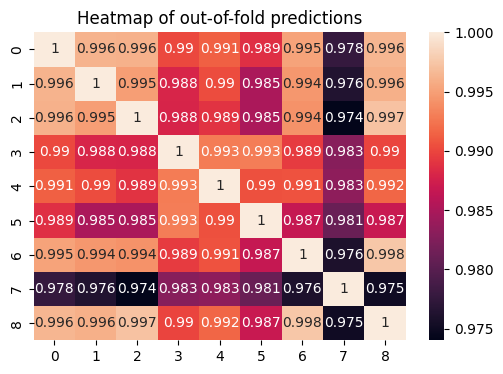

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]


Best blend: 0.970293
Gain: +0.000014

lgbm weight: 0.0018 (0.2%)
xgbm weight: 0.0163 (1.6%)
realmlp weight: 0.2430 (24.3%)
tabpfn weight: 0.0032 (0.3%)
histgbm weight: 0.0031 (0.3%)
catgbm_ord weight: 0.0029 (0.3%)
catgbm weight: 0.0613 (6.1%)
resnet weight: 0.0032 (0.3%)
stack weight: 0.6652 (66.5%)


In [4]:
MODELS = [
    ("lgbm", r"artifacts\oof_proba\lightgbm_v0_seed42_oof_proba.csv", r"artifacts\test_proba\lightgbm_v0_seed42_test_proba.csv"),
    ("xgbm", r"artifacts\oof_proba\xgbm_v0_seed42_oof_proba.csv", r"artifacts\test_proba\xgbm_v0_seed42_test_proba.csv"),
    ("realmlp", r'artifacts\oof_proba\realmlp_v2_seed42_oof_proba.csv', r'artifacts\test_proba\realmlp_v2_seed42_test_proba.csv'),
    ("tabpfn", r'artifacts\oof_proba\tabpfn_v1_seed42_oof_proba.csv', r'artifacts\test_proba\tabpfn_v1_seed42_test_proba.csv'),
    ("histgbm", r'artifacts\oof_proba\histgbm_v2_seed42_oof_proba.csv', r'artifacts\test_proba\histgbm_v2_seed42_test_proba.csv'),
    ("catgbm_ord", r'artifacts\oof_proba\catgbm_ord_v1_seed42_oof_proba.csv', r'artifacts\test_proba\catgbm_ord_v1_seed42_test_proba.csv'),
    ("catgbm", r'artifacts\oof_proba\catgbm_v0_seed42_oof_proba.csv', r'artifacts\test_proba\catgbm_v0_seed42_test_proba.csv'),
    ("resnet", r'artifacts\oof_proba\resnet_v3_seed42_oof_proba.csv', r'artifacts\test_proba\resnet_v3_seed42_test_proba.csv'),
    ("stack", r'artifacts\oof_proba\stack_v0_oof_proba.csv', r'artifacts\test_proba\stack_v0_test_proba.csv')
]

def load_pred(path: str, prob_cols=enc.classes_) -> np.ndarray:
    df = pd.read_csv(path)

    if all(col in df.columns for col in prob_cols):
        return df[prob_cols].to_numpy(dtype=np.float32)

    num_df = df.select_dtypes(include=[np.number])
    if num_df.shape[1] >= 3:
        return num_df.iloc[:, -3:].to_numpy(dtype=np.float32)

    raise ValueError(f"Could not find 3 probability columns in: {path}")


def softmax(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    e = np.exp(x - x.max())
    return e / e.sum()


def weighted_blend(weights: np.ndarray, matrices: list[np.ndarray]) -> np.ndarray:
    """
    matrices: list of shape (n_samples, 3)
    weights: shape (n_models,)
    returns: shape (n_samples, 3)
    """
    blend = np.zeros_like(matrices[0], dtype=np.float32)
    for w, mat in zip(weights, matrices):
        blend += w * mat
    return blend


names = [m[0] for m in MODELS]

# Load once
oof_models = [load_pred(m[1]) for m in MODELS]
test_models = [load_pred(m[2]) for m in MODELS]

# Single-model scores
single_scores = {
    name: balanced_accuracy_score(y, mat.argmax(axis=1))
    for name, mat in zip(names, oof_models)
}

for name, score in single_scores.items():
    print(f"{name} alone: {score:.6f}")

# Optional correlation heatmap
corr = np.corrcoef([mat[:, 0] for mat in oof_models])
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".3g", ax=ax)
ax.set_title("Heatmap of out-of-fold predictions")
plt.show()


def objective(trial):
    raw = np.array(
        [trial.suggest_float(f"w_{name}", -3.0, 3.0) for name in names],
        dtype=np.float32
    )

    weights = softmax(raw)
    blended_oof = weighted_blend(weights, oof_models)
    pred_labels = blended_oof.argmax(axis=1)

    return balanced_accuracy_score(y, pred_labels)


# Phase 1 -> QMC
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.QMCSampler(
        seed=config.SEED,
        qmc_type="sobol",
        scramble=True,
        independent_sampler=optuna.samplers.RandomSampler(seed=config.SEED),
        warn_asynchronous_seeding=True,
        warn_independent_sampling=True,
    ),
)

study.optimize(
    objective,
    n_trials=1000,
    show_progress_bar=True,
    n_jobs=1
)

# Phase 2 -> TPE
study.sampler = optuna.samplers.TPESampler(
    n_ei_candidates=64,
    seed=config.SEED,
    multivariate=False,
    warn_independent_sampling=True,
    n_startup_trials=0,
    constant_liar=True,
)

study.optimize(
    objective,
    n_trials=5000,
    show_progress_bar=True,
    n_jobs=-1
)

# Best weights
best_raw = np.array(
    [study.best_params[f"w_{name}"] for name in names],
    dtype=np.float32
)
best_w = softmax(best_raw)

# Final blend
blend_oof = weighted_blend(best_w, oof_models)
blend_test = weighted_blend(best_w, test_models)

best_single = max(single_scores.values())

print(f"\n{'=' * 50}")
print(f"Best blend: {study.best_value:.6f}")
print(f"Gain: +{study.best_value - best_single:.6f}")
print(f"\n{'=' * 50}")

for name, w in zip(names, best_w):
    print(f"{name} weight: {w:.4f} ({w:.1%})")

In [5]:
RUN_NAME = "myblend_v4"

# Save OOF probabilities
blend_oof_df = pd.DataFrame(
    blend_oof,
    columns=enc.classes_
)
blend_oof_df.insert(0, "id", train_ids)

# Save Test probabilities
blend_test_df = pd.DataFrame(
    blend_test,
    columns=enc.classes_
)
blend_test_df.insert(0, "id", test_ids)

oof_proba_path = Path(
    config.OOF_PROBA_DIR,
    f"{RUN_NAME}_[{study.best_value:.6f}]_oof_proba.csv"
)

test_proba_path = Path(
    config.TEST_PROBA_DIR,
    f"{RUN_NAME}_[{study.best_value:.6f}]_test_proba.csv"
)

blend_oof_df.to_csv(oof_proba_path, index=False)
blend_test_df.to_csv(test_proba_path, index=False)

# Sanity check
sanity_oof = pd.read_csv(oof_proba_path)

sanity_pred = (sanity_oof[enc.classes_].to_numpy().argmax(axis=1))
sanity_score = balanced_accuracy_score(y,sanity_pred)
print("Sanity score:", sanity_score)

Sanity score: 0.9702930933951589


In [6]:
# Saving submission file as class labels
test_proba = pd.read_csv(test_proba_path)

# class with highest probability
pred_class_idx = test_proba[enc.classes_].to_numpy().argmax(axis=1)

# Integer encoding -> class labels
pred_class_labels = enc.inverse_transform(pred_class_idx)

submission_df = pd.DataFrame({
    "id": test_ids,
    "class": pred_class_labels
})

submission_df.to_csv(Path(config.SUBMISSION_DIR, f"{RUN_NAME}_[{sanity_score:.5f}]submission.csv"),index=False)

test_proba_path.unlink()
oof_proba_path.unlink()
print("File successfully deleted from disk!")

File successfully deleted from disk!


### Stacking

In [10]:
# Load multiclass OOF/test probabilities and create one meta-feature per model-class pair

oof_files = sorted(config.OOF_PROBA_DIR.glob("*_oof_proba.csv"))

oof_df = pd.DataFrame({"id": train_ids})
test_df = pd.DataFrame({"id": test_ids})

used_models = []

for i, oof_file in enumerate(oof_files, start=1):

    model_name = oof_file.stem.replace("_oof_proba", "")
    test_file = config.TEST_PROBA_DIR / f"{model_name}_test_proba.csv"

    if not test_file.exists():
        print(f"Skipping {model_name} (test file missing)")
        continue

    oof_preds = pd.read_csv(oof_file)
    test_preds = pd.read_csv(test_file)

    class_cols = [c for c in oof_preds.columns if c != "id"]

    for cls in class_cols:
        feat = f"model_{i}_{cls}"
        oof_df[feat] = oof_preds[cls].values
        test_df[feat] = test_preds[cls].values

    used_models.append(model_name)

print(f"Using {len(used_models)} matched models")

FEATURES = [c for c in oof_df.columns if c != "id"]

X_meta = oof_df[FEATURES].values
X_meta_test = test_df[FEATURES].values
y_meta = np.asarray(y)

print(f"OOF shape: {X_meta.shape}")
print(f"Test shape: {X_meta_test.shape}")
print(f"Total meta features: {len(FEATURES)}")

Using 32 matched models
OOF shape: (577347, 96)
Test shape: (247435, 96)
Total meta features: 96


In [11]:
print(X_meta.shape)
print(X_meta_test.shape)
print(y_meta.shape)

(577347, 96)
(247435, 96)
(577347,)


In [12]:
# Optuna feature selection + Logistic Regression meta model
def objective(trial):

    # Let Optuna decide which features to keep
    selected_cols = [
        col
        for col in FEATURES
        if trial.suggest_int(f"use_{col}", 0, 1)
    ]

    # Avoid training on an empty feature set
    if len(selected_cols) == 0:
        return 0.5

    X_selected = oof_df[selected_cols].values

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for fold, (tr_idx, val_idx) in enumerate(
        skf.split(X_selected, y_meta)
    ):

        X_tr = X_selected[tr_idx]
        X_val = X_selected[val_idx]

        y_tr = y_meta[tr_idx]
        y_val = y_meta[val_idx]

        # Simple standardized logistic regression stacker
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=2,
                max_iter=100,
                random_state=config.SEED,
            )
        )

        model.fit(X_tr, y_tr)

        val_preds = model.predict(X_val)

        fold_score = balanced_accuracy_score(
            y_val,
            val_preds
        )

        scores.append(fold_score)

        # Report intermediate score for pruning
        trial.report(
            np.mean(scores),
            step=fold
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


# Create study
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    ),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10
    )
)

# Run optimization
study.optimize(
    objective,
    n_trials=500,
    n_jobs=1,
    show_progress_bar=True
)

print(f"Best CV Score: {study.best_value:.6f}")
print()

print("Selected Features:")
best_features = [
    col
    for col in FEATURES
    if study.best_trial.params.get(f"use_{col}", 0) == 1
]

for col in best_features:
    print(col)

print()
print("Best Parameters:")
print(study.best_trial.params)

  0%|          | 0/500 [00:00<?, ?it/s]

Best CV Score: 0.966745

Selected Features:
model_1_STAR
model_2_STAR
model_4_QSO
model_11_GALAXY
model_11_QSO
model_12_GALAXY
model_15_GALAXY
model_15_STAR
model_17_GALAXY
model_18_GALAXY
model_19_GALAXY
model_19_STAR
model_20_STAR
model_21_GALAXY

Best Parameters:
{'use_model_1_GALAXY': 0, 'use_model_1_QSO': 0, 'use_model_1_STAR': 1, 'use_model_2_GALAXY': 0, 'use_model_2_QSO': 0, 'use_model_2_STAR': 1, 'use_model_3_GALAXY': 0, 'use_model_3_QSO': 0, 'use_model_3_STAR': 0, 'use_model_4_GALAXY': 0, 'use_model_4_QSO': 1, 'use_model_4_STAR': 0, 'use_model_5_GALAXY': 0, 'use_model_5_QSO': 0, 'use_model_5_STAR': 0, 'use_model_6_GALAXY': 0, 'use_model_6_QSO': 0, 'use_model_6_STAR': 0, 'use_model_7_GALAXY': 0, 'use_model_7_QSO': 0, 'use_model_7_STAR': 0, 'use_model_8_GALAXY': 0, 'use_model_8_QSO': 0, 'use_model_8_STAR': 0, 'use_model_9_GALAXY': 0, 'use_model_9_QSO': 0, 'use_model_9_STAR': 0, 'use_model_10_GALAXY': 0, 'use_model_10_QSO': 0, 'use_model_10_STAR': 0, 'use_model_11_GALAXY': 1, 'us

In [ ]:
# best models
best_cols = [
    col for col in FEATURES
    if study.best_params[f"use_{col}"] == 1
]

In [ ]:
X_best = oof_df[best_cols].values
X_best_test = test_df[best_cols].values
y_meta = np.asarray(y)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=config.SEED
)

oof_preds = np.zeros(len(X_best))
test_preds = np.zeros(len(X_best_test))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_best, y_meta), start=1):

    X_tr, X_val = X_best[tr_idx], X_best[val_idx]
    y_tr, y_val = y_meta[tr_idx], y_meta[val_idx]

    model = pipe(
        StandardScaler(),
        LogisticRegression(C=2, max_iter=400)
    )

    model.fit(X_tr, y_tr)

    val_preds = model.predict_proba(X_val)
    tst_preds = model.predict_proba(X_best_test)

    oof_preds[val_idx] = val_preds
    test_preds += tst_preds / config.N_FOLDS

    fold_bacc = balanced_accuracy_score(y_val, np.argmax(val_preds))
    print(f"Fold {fold} BACC: {fold_bacc:.6f}")

final_bacc = balanced_accuracy_score(y_meta, np.argmax(oof_preds))
print(f"\nOOF BACC: {final_bacc:.6f}")

In [ ]:
oof_df_out = pd.DataFrame({"id": train_ids, "PitNextLap": oof_preds})
test_df_out = pd.DataFrame({"id": test_ids, "PitNextLap": test_preds})

oof_df_out.to_csv(config.OOF_PROBA_DIR / "stack_v1_oof_proba.csv")
test_df_out.to_csv(config.TEST_PROBA_DIR / "stack_v1_test_proba.csv")